# From picks to a catalog with GaMMA

Notebook 05 produced a pile of picks: a phase name, a time, and the station
it came from. A pile of picks is not a catalog. Turning one into the other
means deciding **which picks belong to the same earthquake**, and then where
and when that earthquake was — association and location, in one step.

[GaMMA](https://github.com/AI4EPS/GaMMA) does that by treating the picks as a
Gaussian mixture in which each component is an earthquake, and the travel
time from a hypocentre is the mean. It is a good fit for DAS precisely
because it does not care how many "stations" there are.

```{note}
The install is `pip install git+https://github.com/AI4EPS/GaMMA.git`, and
mind the name: the distribution is called `gmma` but you `import gamma`. The
package on PyPI called `GaMMA` is something else entirely.
```

In [1]:
import numpy as np
import pandas as pd
import pyproj
from obspy import read_inventory

from gamma.utils import association

## The two tables GaMMA wants

A **stations** table, positioned in a local Cartesian frame in kilometres,
and a **picks** table keyed by the same station ids.

In [2]:
picks = pd.read_csv("outputs/station_picks.csv", parse_dates=["time"])
inventory = read_inventory("data/stations/stations.xml")

rows = [
    (f"{net.code}.{sta.code}", sta.latitude, sta.longitude, sta.elevation)
    for net in inventory
    for sta in net
]
stations = pd.DataFrame(
    rows, columns=["id", "latitude", "longitude", "elevation"]
).drop_duplicates("id")

An azimuthal-equidistant projection centred on the network turns degrees
into kilometres, which is what the travel-time calculation needs:

In [3]:
proj = pyproj.Proj(
    proj="aeqd",
    lat_0=stations["latitude"].mean(),
    lon_0=stations["longitude"].mean(),
    units="km",
)
stations["x(km)"], stations["y(km)"] = proj(
    stations["longitude"].values, stations["latitude"].values
)
stations["z(km)"] = -stations["elevation"] / 1000.0
stations = stations[stations["id"].isin(set("C1." + picks["station"]))]
stations

,id,latitude,longitude,elevation,x(km),y(km),z(km)
9,C1.CO01,-29.97730,-70.09390,2157.0,98.807396,89.672232,-2.157
10,C1.CO02,-31.20370,-71.00030,1190.0,11.188702,-45.847080,-1.190
11,C1.CO03,-30.83890,-70.68910,1003.0,41.001996,-5.474415,-1.003
12,C1.CO04,-32.04330,-70.97470,2401.0,13.507541,-138.944982,-2.401
13,C1.CO05,-29.91864,-71.23841,101.0,-11.656478,96.616871,-0.101
18,C1.VA06,-32.56117,-71.29765,80.0,-16.902025,-196.377769,-0.080


The picks table needs four columns under GaMMA's own names — the station
`id`, the `timestamp`, the phase `type` in lower case, and the model's
confidence as `prob`:

In [4]:
gamma_picks = pd.DataFrame(
    {
        "id": picks["network"] + "." + picks["station"],
        "timestamp": picks["time"],
        "type": picks["phase"].str.lower(),
        "prob": picks["value"],
    }
)
gamma_picks

,id,timestamp,type,prob
0,C1.CO01,2023-11-03 12:27:14.100,p,0.698469
1,C1.CO01,2023-11-03 12:27:30.820,s,0.780952
2,C1.CO02,2023-11-03 12:27:14.500,p,0.715877
3,C1.CO02,2023-11-03 12:27:33.460,s,0.420162
4,C1.CO03,2023-11-03 12:27:11.700,p,0.911087
5,C1.CO03,2023-11-03 12:27:27.840,s,0.536183
6,C1.CO04,2023-11-03 12:27:27.130,p,0.482442
7,C1.CO04,2023-11-03 12:27:53.550,s,0.363163
8,C1.CO05,2023-11-03 12:26:57.420,p,0.967788
9,C1.CO05,2023-11-03 12:27:03.020,s,0.860738


## Configuring the association

The search volume, a velocity model (two constants here — a real study would
pass an eikonal solver), and the thresholds that decide when a cluster of
picks is convincing enough to be called an earthquake:

In [5]:
xlim = (stations["x(km)"].min() - 50, stations["x(km)"].max() + 50)
ylim = (stations["y(km)"].min() - 50, stations["y(km)"].max() + 50)
zlim = (0.0, 60.0)

config = {
    "dims": ["x(km)", "y(km)", "z(km)"],
    "x(km)": xlim,
    "y(km)": ylim,
    "z(km)": zlim,
    "bfgs_bounds": (xlim, ylim, zlim, (None, None)),
    "use_dbscan": True,
    "dbscan_eps": 25.0,
    "dbscan_min_samples": 3,
    "use_amplitude": False,  # we did not measure amplitudes, so no magnitudes
    "vel": {"p": 6.0, "s": 6.0 / 1.75},
    "method": "BGMM",
    "oversample_factor": 4,
    "min_picks_per_eq": 8,
    "max_sigma11": 2.0,
    "max_sigma22": 1.0,
    "max_sigma12": 1.0,
    "ncpu": 1,
}

In [6]:
events, assignments = association(gamma_picks, stations, config, method="BGMM")
print(f"{len(events)} event(s) from {len(gamma_picks)} picks")

Clustering (eps=20.83): 100%|██████████| 2/2 [00:00<00:00, 22671.91it/s]

Associating 12 picks with 1 CPUs
.1 event(s) from 12 picks



/Users/trabatto/pkgs/tutorials/.venv/lib/python3.12/site-packages/gamma/seismic_ops.py:302: OptimizeWarning: Unknown solver options: iprint
  opt = scipy.optimize.minimize(


## The catalog

In [7]:
catalog = pd.DataFrame(events)
catalog["longitude"], catalog["latitude"] = proj(
    catalog["x(km)"].values, catalog["y(km)"].values, inverse=True
)
catalog = catalog.rename(columns={"z(km)": "depth(km)"})
catalog[
    ["time", "latitude", "longitude", "depth(km)", "num_picks", "gamma_score", "sigma_time"]
]

,time,latitude,longitude,depth(km),num_picks,gamma_score,sigma_time
0,2023-11-03T12:26:49.753,-29.97883,-71.515393,36.333727,8,9.0,0.328128


In [8]:
catalog.to_csv("outputs/catalog.csv", index=False)

One earthquake, with an origin time, a hypocentre and a residual — built
from nothing but waveforms and a pretrained model. Worth noting that the
USGS and EMSC catalogs both have **nothing** at this time and place: at this
magnitude, in this region, we are not rediscovering a known event.

Drawn on a map, with the stations that contributed:

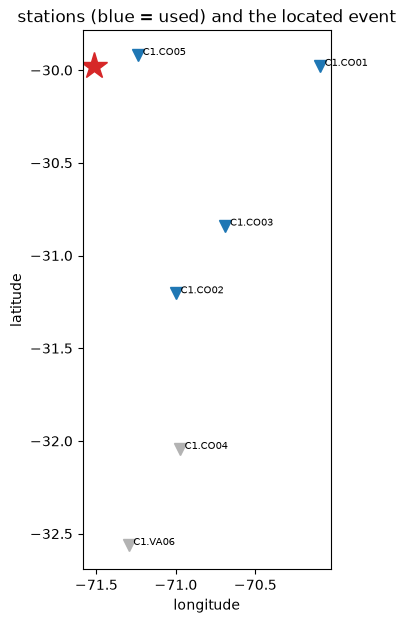

In [9]:
import matplotlib.pyplot as plt

assigned = pd.DataFrame(assignments, columns=["pick_index", "event_index", "prob"])
used = set(gamma_picks.loc[assigned["pick_index"], "id"])

fig, ax = plt.subplots(figsize=(7, 7))
for _, station in stations.iterrows():
    contributed = station["id"] in used
    ax.plot(
        station["longitude"],
        station["latitude"],
        "v",
        ms=9,
        c="C0" if contributed else "0.7",
    )
    ax.text(station["longitude"] + 0.03, station["latitude"], station["id"], fontsize=7)
ax.plot(catalog["longitude"], catalog["latitude"], "*", ms=20, c="C3")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("stations (blue = used) and the located event")
ax.set_aspect(1 / np.cos(np.deg2rad(31)))
plt.show()

## Checking it arrival by arrival

A location is a hypothesis. The honest test is to predict every arrival from
it and look at the residuals:

In [10]:
from obspy.geodetics import gps2dist_azimuth

event = catalog.iloc[0]
origin = pd.Timestamp(event["time"])
velocity = {"P": config["vel"]["p"], "S": config["vel"]["s"]}

check = gamma_picks.copy()
check["phase"] = picks["phase"].values
coords = stations.set_index("id")
distances = []
for _, row in check.iterrows():
    station = coords.loc[row["id"]]
    metres, _, _ = gps2dist_azimuth(
        event["latitude"], event["longitude"], station["latitude"], station["longitude"]
    )
    distances.append(np.hypot(metres / 1000.0, event["depth(km)"]))
check["hypo(km)"] = distances
check["predicted"] = [
    origin + pd.Timedelta(seconds=d / velocity[p])
    for d, p in zip(check["hypo(km)"], check["phase"])
]
check["residual(s)"] = (check["timestamp"] - check["predicted"]).dt.total_seconds()
check.sort_values("hypo(km)")[["id", "phase", "hypo(km)", "residual(s)"]]

,id,phase,hypo(km),residual(s)
8,C1.CO05,P,45.602858,0.066524
9,C1.CO05,S,45.602858,-0.033834
4,C1.CO03,P,129.285646,0.399392
5,C1.CO03,S,129.285646,0.378687
0,C1.CO01,P,141.913984,0.694669
1,C1.CO01,S,141.913984,-0.324579
2,C1.CO02,P,148.996677,-0.085780
3,C1.CO02,S,148.996677,0.249636
6,C1.CO04,P,237.433735,-2.195289
7,C1.CO04,S,237.433735,-5.454506


Most residuals are a few tenths of a second, which is as much as two
constant velocities can be expected to deliver. Two of them are enormous —
tens of seconds — and those are the `VA06` picks: at 287 km, that station
recorded nothing, and the picker labelled noise. GaMMA left them out, which
is exactly what an associator is for.

The far station drifts too, by a few seconds at 235 km, for the same reason:
a single P velocity cannot describe a path that samples the whole crust.

## What the cable adds

The DAS never entered the association, so it is an independent check.
S−P at a channel gives a hypocentral distance without knowing anything about
where the event is:

In [11]:
das = pd.read_csv("outputs/picks.csv", parse_dates=["time"])
first_p = das[das["phase"] == "P"].groupby("distance")["time"].min()
first_s = das[das["phase"] == "S"].groupby("distance")["time"].min()
both = first_p.index.intersection(first_s.index)
sp = (first_s[both] - first_p[both]).dt.total_seconds()

# the median, because a few channels have spurious picks
slowness = 1 / velocity["S"] - 1 / velocity["P"]
print(f"channels with both phases : {len(both)}")
print(f"median S-P                : {sp.median():.2f} s")
print(f"implied hypocentral range : {sp.median() / slowness:.0f} km")
print(f"catalog depth             : {event['depth(km)']:.0f} km")
print(f"first DAS P               : {first_p.min()}")
print(f"  i.e. {(first_p.min() - origin).total_seconds():.2f} s after the origin time")

channels with both phases : 163
median S-P                : 4.52 s
implied hypocentral range : 36 km
catalog depth             : 36 km
first DAS P               : 2023-11-03 12:20:13.720000
  i.e. -396.03 s after the origin time


Those two numbers are measuring nearly the same thing. The cable sits almost
above the source, so its distance to the hypocentre *is* essentially the
depth — and an independent S−P measurement on the fiber agrees with the
network's depth to within a few kilometres. For an eight-pick location and a
velocity model of two constants, that is about as well as it can be expected
to do.

## Putting the fiber into the association

The cable is currently only a witness. Making it a participant means adding
its channels to the association as stations — GaMMA has no notion of "DAS",
a channel is a point that recorded a phase at a time.

That needs one thing this tutorial does not yet have: **where each channel
physically is**. With `data/geometry/SER_N.csv` in place, it looks like this:

In [12]:
from pathlib import Path

if Path("data/geometry/SER_N.csv").exists():
    geometry = pd.read_csv("data/geometry/SER_N.csv")

    das_decimated = das[das["distance"].isin(das["distance"].unique()[::100])]
    das_stations = pd.DataFrame(
        {
            "id": "DAS." + geometry.index.astype(str),
            "latitude": geometry["latitude"],
            "longitude": geometry["longitude"],
        }
    )
    print(f"would add {len(das_stations)} DAS channels to the association")
else:
    print("no cable geometry yet: data/geometry/SER_N.csv")
    print("columns expected: distance, latitude, longitude")

no cable geometry yet: data/geometry/SER_N.csv
columns expected: distance, latitude, longitude
